<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P4_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°4 — Modélisation & Évaluation

Contenu :
- Import des données transformées (sortie du P3)
- Gestion du déséquilibre (Undersampling)
- Feature Selection
- Évaluation LightGBM (Cross-Validation 5-fold)
- Optimisation du modèle
- Évaluation finale sur le Test Set (une seule fois)
- Interprétabilité et conclusions

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sps
import seaborn as sns

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [14]:
train_X = pd.read_parquet("DATA/03_train_X.parquet")
train_y = pd.read_parquet("DATA/03_train_y.parquet").squeeze()
test_X = pd.read_parquet("DATA/03_test_X.parquet")
test_y = pd.read_parquet("DATA/03_test_y.parquet").squeeze()

# Lecture du nom de la cible (pour les fonctions utilitaires)
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Train X : {train_X.shape} | Train y : {train_y.shape}")
print(f"Test  X : {test_X.shape}  | Test  y : {test_y.shape}")
print(f"\nRatio défaut train : {train_y.mean():.2%}")
print(f"Ratio défaut test  : {test_y.mean():.2%}")

Train X : (1025966, 86) | Train y : (1025966,)
Test  X : (256492, 86)  | Test  y : (256492,)

Ratio défaut train : 21.57%
Ratio défaut test  : 21.57%


### Gestion du déséquilibre des classes

**Pourquoi privilégier l'Undersampling plutôt que SMOTE ou les paramètres de poids (`is_unbalance=True`, `scale_pos_weight`) ?**

Bien que des algorithmes comme LightGBM proposent des paramètres intégrés (`is_unbalance=True` ou `scale_pos_weight`) et que la génération de données synthétiques (comme SMOTE) soit populaire, nous avons opté pour un **Undersampling (sous-échantillonnage) de la classe majoritaire** pour plusieurs raisons clés, particulièrement adaptées au contexte de Lending Club :

1. **Volume des données et temps de calcul :** Le jeu de données est massif (plusieurs centaines de milliers de lignes). L'undersampling réduit considérablement la taille du jeu de données d'entraînement. Cela accélère drastiquement l'apprentissage et surtout les étapes d'optimisation des hyperparamètres (GridSearch/RandomSearch). À l'inverse, SMOTE augmenterait encore la taille du dataset, rendant l'entraînement extrêmement long et gourmand en mémoire.
2. **Redondance de la classe majoritaire :** La classe majoritaire (prêts remboursés) est tellement représentée (plus de 80% des données) qu'en supprimer une partie de manière aléatoire n'entraîne pas de perte d'information significative. Le modèle disposera toujours de suffisamment d'exemples pour comprendre le profil d'un bon payeur.
3. **Risque de bruit avec SMOTE :** SMOTE génère des échantillons synthétiques par interpolation spatiale. Sur des données tabulaires complexes mêlant variables continues et variables catégorielles encodées, cette interpolation peut créer des individus irréalistes (du bruit) et favoriser le surapprentissage (overfitting). L'undersampling n'utilise que des données 100% réelles.
4. **Clarté du signal :** Utiliser `scale_pos_weight` ou `is_unbalance=True` conserve toute la masse de la classe majoritaire mais pénalise plus lourdement les erreurs sur la classe minoritaire. Avec un déséquilibre fort sur un très gros volume, le nettoyage pur et simple de la classe majoritaire permet souvent au modèle d'isoler un signal plus clair et plus distinct entre les deux classes sans biaiser artificiellement la fonction de coût.

In [15]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
# On crée un jeu d'entraînement rééquilibré
train_X_model, train_y_model = undersampler.fit_resample(train_X, train_y)

print(f"Undersampling : {train_X_model.shape}")
print(train_y_model.value_counts())

Undersampling : (442580, 86)
loan_condition_int
0    221290
1    221290
Name: count, dtype: int64


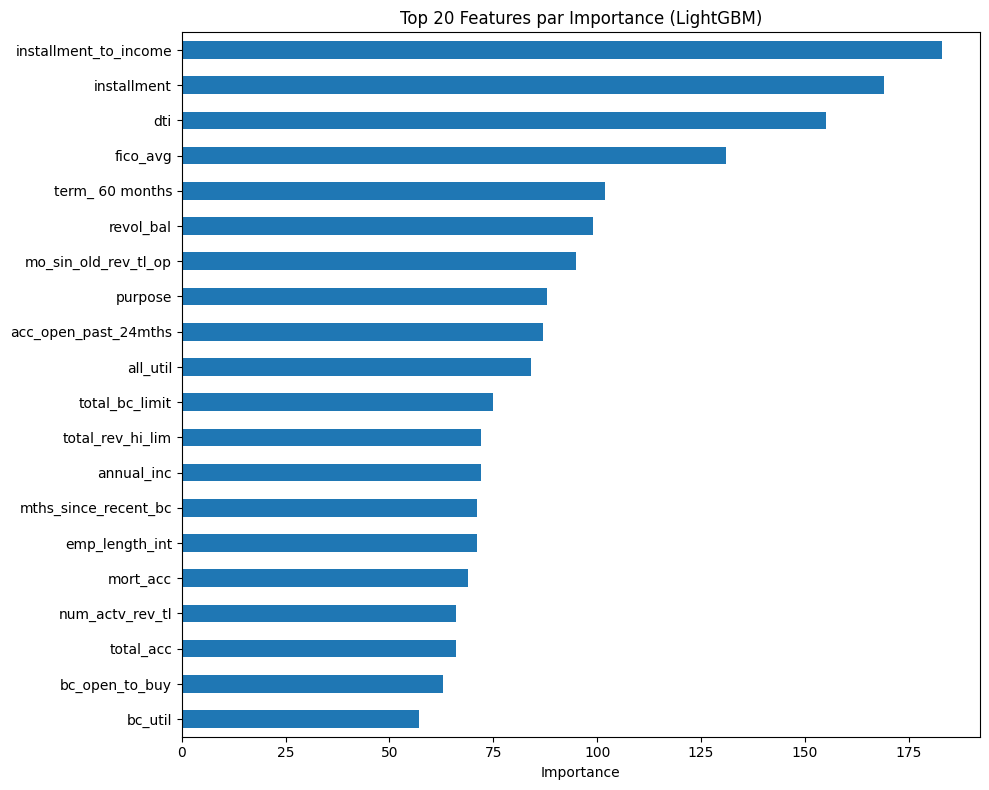


15 features retenues : ['installment_to_income', 'installment', 'dti', 'fico_avg', 'term_ 60 months', 'revol_bal', 'mo_sin_old_rev_tl_op', 'purpose', 'acc_open_past_24mths', 'all_util', 'total_bc_limit', 'total_rev_hi_lim', 'annual_inc', 'mths_since_recent_bc', 'emp_length_int']


In [16]:
# Méthode : Feature Importance via un modèle LightGBM rapide
from lightgbm import LGBMClassifier

# Entraîner un modèle rapide pour obtenir les importances
lgbm_quick = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgbm_quick.fit(train_X_model, train_y_model)

# Extraire et afficher les importances
importances = pd.Series(lgbm_quick.feature_importances_, index=train_X_model.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Features par Importance (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Sélectionner les features avec importance > 0 (ou un seuil personnalisé)
N_TOP_FEATURES = 15
vars_final = importances.head(N_TOP_FEATURES).index.tolist()
print(f"\n{N_TOP_FEATURES} features retenues : {vars_final}")

# Filtrer train et test
train_X_selected = train_X_model[vars_final]
test_X_selected = test_X[vars_final]

Pour justifier le choix de **LightGBM** par rapport aux autres modèles que nous avons testés (Régression Logistique, Arbre de Décision, KNN, Random Forest, Naive Bayes, XGBoost, Gradient Boosting, Réseau de Neurones), nous avons structurer notre argumentaire autour de ces points clés, particulièrement adaptés au jeu de données **Lending Club** (qui est volumineux et tabulaire) :

**1. Vitesse d'entraînement et efficacité mémoire (Le point fort face à XGBoost et Random Forest)**
*   Contrairement à XGBoost (dans son fonctionnement classique) ou Random Forest qui font croître les arbres niveau par niveau (*level-wise*), LightGBM utilise une croissance par feuille (*leaf-wise*). De plus, il utilise une technique basée sur des histogrammes pour regrouper les valeurs continues.
*   **Résultat :** Il est significativement **plus rapide** à entraîner et consomme **beaucoup moins de mémoire**. Sur un jeu de données massif comme celui de Lending Club, ce gain de temps est crucial pour pouvoir itérer et optimiser les hyperparamètres rapidement.

**2. Supériorité sur les données tabulaires (Face à KNN, SVM, Naïve Bayes et Réseaux de Neurones)**
*   Pour des données structurées/tabulaires contenant un mélange de variables continues et catégorielles (revenus, durée du prêt, taux, etc.), les algorithmes de boosting de gradient (comme LightGBM et XGBoost) dominent historiquement les compétitions de type Kaggle. Ils performent généralement mieux que les réseaux de neurones complexes ou les modèles basés sur la distance comme le KNN (très lent et sensible à la malédiction de la dimensionnalité).


**3. Interprétabilité du modèle (Face aux Réseaux de Neurones)**
*   Dans le domaine du risque de crédit, l'interprétabilité est une exigence métier et parfois légale. Si un modèle de réseau de neurones (`MLPClassifier`) agit comme une "boîte noire", LightGBM permet de calculer très facilement l'**importance des features** (savoir que l'historique de crédit ou le taux d'endettement a été déterminant dans le refus d'un prêt). Il est aussi parfaitement compatible avec des outils de type SHAP values pour expliciter localement des décisions.

**4. Robustesse face au déséquilibre des classes**
*   Le cas d'usage de Lending Club consiste généralement à prédire la probabilité de défaut. Il s'agit de jeux de données où les "défauts de paiement" sont minoritaires face aux prêts remboursés.
*   LightGBM gère nativement le déséquilibre des classes de façon très performante, notamment grâce aux poids (paramètres comme `is_unbalance` ou `scale_pos_weight`).

**En résumé :**
**LightGBM offre le meilleur compromis de notre benchmark** : il atteint des performances prédictives de pointe (supérieures à Random Forest et XGBoost), tout en divisant les temps de calcul de manière drastique, et ce de manière parfaitement transparente et interprétable pour un contexte financier.

In [17]:
# Optimisation de LightGBM avec RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entraîner sur le jeu d'entraînement rééquilibré (features sélectionnées)
search.fit(train_X_selected, train_y_model)

print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleure Average Precision (CV) : {search.best_score_:.4f}")

best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres : {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleure Average Precision (CV) : 0.7003


RÉSUMÉ DES MÉTRIQUES CLÉS - TEST SET
🔹 AUPRC (Average Precision) : 0.4083 → Robustesse globale du modèle (indépendant du déséquilibre).
🔹 Recall (Classe 1)         : 0.6670 → Protection du capital : taux de détection des vrais défauts.
🔹 F2-Score                  : 0.5616 → Métrique métier : accorde 2x plus de poids au Recall qu'à la Précision.
🔹 KS Statistic              : 0.3178 → Séparation des distributions (Bon vs Mauvais crédit).


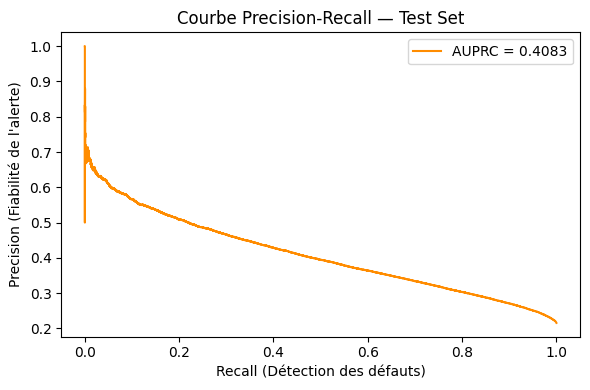

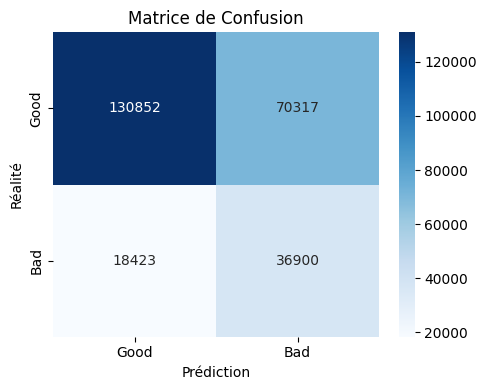

In [18]:
from sklearn.metrics import fbeta_score, average_precision_score

# On établit l'évaluation finale sur le test set
y_pred = best_model.predict(test_X_selected)
y_pred_proba = best_model.predict_proba(test_X_selected)[:, 1]

# Calcul des métriques essentielles
recall_classe1 = recall_score(test_y, y_pred)
f2_score = fbeta_score(test_y, y_pred, beta=2)
auprc = average_precision_score(test_y, y_pred_proba)

# KS Statistic
mask = test_y.astype(bool).values
ks_stat = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

print("=" * 60)
print("RÉSUMÉ DES MÉTRIQUES CLÉS - TEST SET")
print("=" * 60)
print(f"🔹 AUPRC (Average Precision) : {auprc:.4f} → Robustesse globale du modèle (indépendant du déséquilibre).")
print(f"🔹 Recall (Classe 1)         : {recall_classe1:.4f} → Protection du capital : taux de détection des vrais défauts.")
print(f"🔹 F2-Score                  : {f2_score:.4f} → Métrique métier : accorde 2x plus de poids au Recall qu'à la Précision.")
print(f"🔹 KS Statistic              : {ks_stat:.4f} → Séparation des distributions (Bon vs Mauvais crédit).")
print("=" * 60)

# Courbe Precision-Recall (pour appui visuel de l'AUPRC)
precision_curve, recall_curve, _ = precision_recall_curve(test_y, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AUPRC = {auprc:.4f}', color='darkorange')
plt.xlabel('Recall (Détection des défauts)')
plt.ylabel('Precision (Fiabilité de l\'alerte)')
plt.title('Courbe Precision-Recall — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# Matrice de confusion rapide (pour la lisibilité)
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

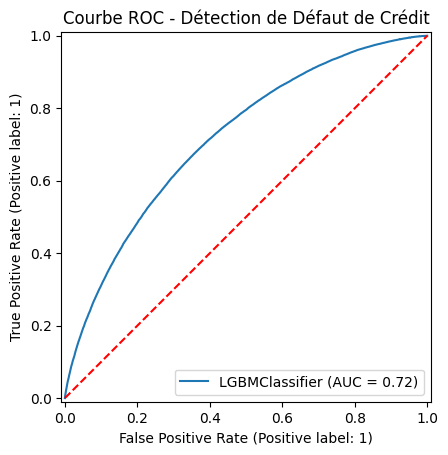

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, test_X_selected, test_y)
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Ligne de hasard
plt.title("Courbe ROC - Détection de Défaut de Crédit")
plt.show()

In [20]:
from sklearn.metrics import precision_score, roc_auc_score, classification_report

# 1. Calcul des prédictions (classes et probabilités)
# Remplace 'X_test' et 'y_test' par les noms de tes variables si elles sont différentes
y_pred = best_model.predict(test_X_selected)
y_proba = best_model.predict_proba(test_X_selected)[:, 1]

# 2. Calcul des métriques spécifiques
precision = precision_score(test_y, y_pred)
auc_roc = roc_auc_score(test_y, y_proba)

# 3. Affichage propre
print(f"========================================")
print(f"   RÉSULTATS FINAUX DU MODÈLE LGBM")
print(f"========================================")
print(f"Précision (Classe 1 - Bad Loan) : {precision:.4f}")
print(f"AUC-ROC Score                   : {auc_roc:.4f}")
print(f"========================================")

# Optionnel : Afficher le rapport complet pour voir la précision de la classe 0 aussi
print("\nDétails par classe :")
print(classification_report(test_y, y_pred))

   RÉSULTATS FINAUX DU MODÈLE LGBM
Précision (Classe 1 - Bad Loan) : 0.3442
AUC-ROC Score                   : 0.7186

Détails par classe :
              precision    recall  f1-score   support

           0       0.88      0.65      0.75    201169
           1       0.34      0.67      0.45     55323

    accuracy                           0.65    256492
   macro avg       0.61      0.66      0.60    256492
weighted avg       0.76      0.65      0.68    256492



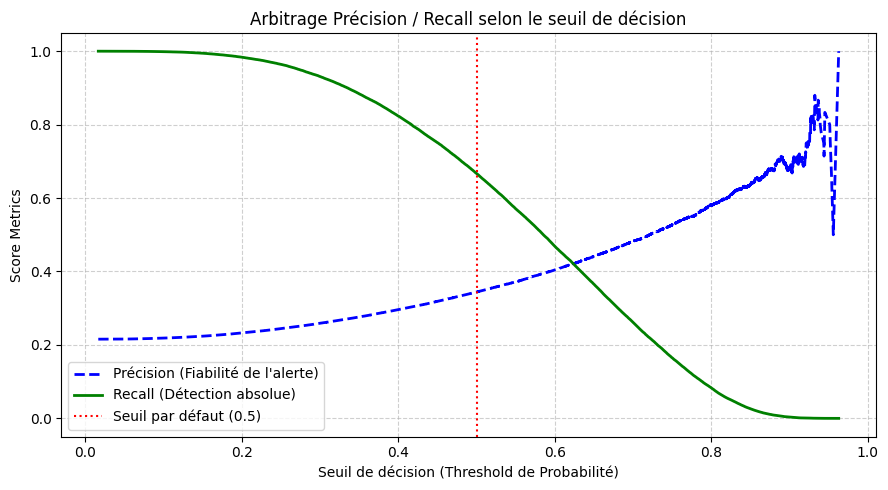

   SIMULATION : IMPACT DU SEUIL DÉCISION
Seuil ~0.30 ➔ Précision: 25.91% | Recall: 93.11%
Seuil ~0.40 ➔ Précision: 29.61% | Recall: 82.34%
Seuil ~0.50 ➔ Précision: 34.42% | Recall: 66.70%
Seuil ~0.60 ➔ Précision: 40.42% | Recall: 46.86%
Seuil ~0.70 ➔ Précision: 48.27% | Recall: 26.15%
Seuil ~0.80 ➔ Précision: 58.06% | Recall: 8.28%


In [21]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Calcul des Précisions, Recalls et Seuils
precisions, recalls, thresholds = precision_recall_curve(test_y, y_proba)

# --- 1. Tracer le graphique Precision / Recall selon le seuil ---
plt.figure(figsize=(9, 5))
# On trace jusqu'à l'avant-dernier élément car la taille de thresholds est len(precisions) - 1
plt.plot(thresholds, precisions[:-1], "b--", label="Précision (Fiabilité de l'alerte)", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Détection absolue)", linewidth=2)

# Ligne verticale indiquant le seuil standard par défaut à 0.5
plt.axvline(x=0.5, color='red', linestyle=':', label='Seuil par défaut (0.5)')

plt.xlabel("Seuil de décision (Threshold de Probabilité)")
plt.ylabel("Score Metrics")
plt.title("Arbitrage Précision / Recall selon le seuil de décision")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- 2. Affichage d'un tableau d'aide à la décision (Simulation Métier) ---
thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print("========================================")
print("   SIMULATION : IMPACT DU SEUIL DÉCISION")
print("========================================")
for t in thresholds_to_check:
    # Trouver l'indice du seuil le plus proche de la cible étudiée
    idx = np.argmin(np.abs(thresholds - t))
    print(f"Seuil ~{thresholds[idx]:.2f} ➔ Précision: {precisions[idx]:.2%} | Recall: {recalls[idx]:.2%}")

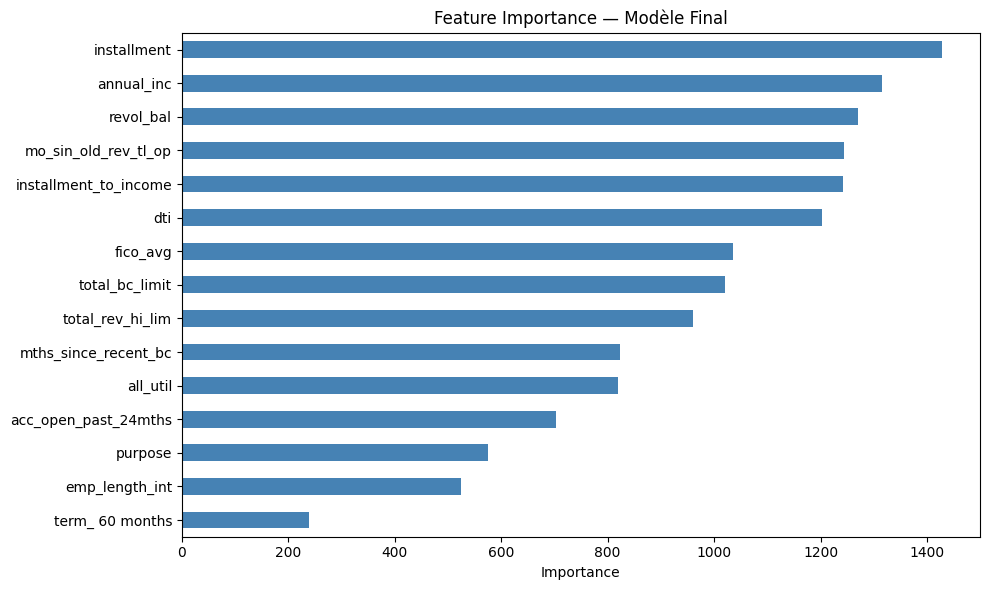

In [22]:
# Feature Importance du modèle final
importances_final = pd.Series(best_model.feature_importances_,
                               index=test_X_selected.columns)
importances_final = importances_final.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_final.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Modèle Final")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

c:\Users\talib\Desktop\lending-club-prediction\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


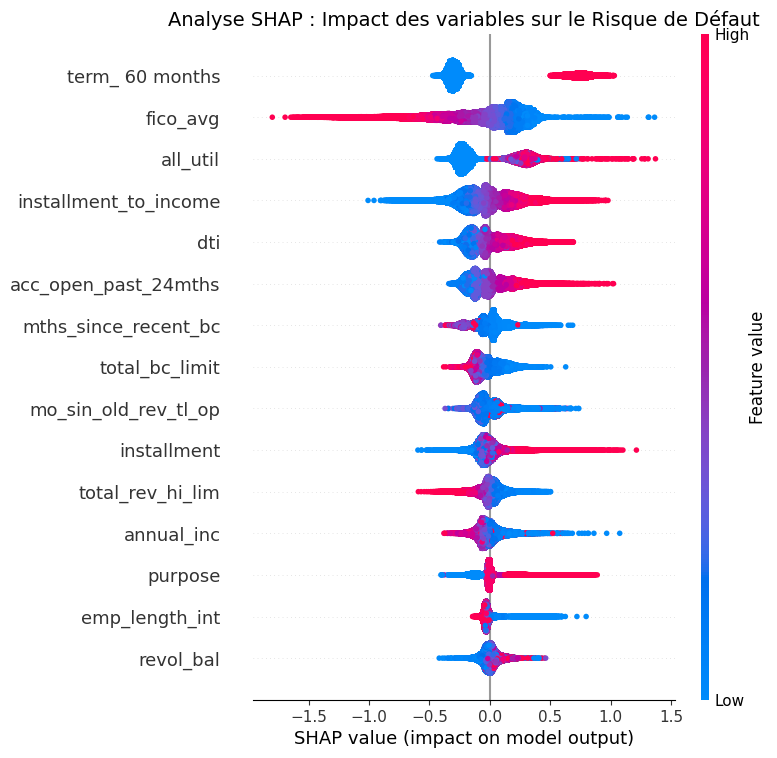

In [23]:
# SHAP Values
import shap

# 1. Calculer les SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(test_X_selected)

# 2. Afficher le plot (Correction de l'erreur de matrice)
plt.figure(figsize=(10, 8))

# Si shap_values est une liste (souvent avec LightGBM), on prend l'index 1
# Sinon, on prend directement shap_values
values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(values_to_plot, test_X_selected, show=False)
plt.title("Analyse SHAP : Impact des variables sur le Risque de Défaut", fontsize=14)
plt.show()


---
### (Bonus) Comparaison avec le Sur-échantillonnage (SMOTE)
L'undersampling réduit considérablement la taille du dataset d'entraînement. Regardons si la génération de données synthétiques sur la classe minoritaire via SMOTE permet de gagner en performance, notamment sur notre F2-Score ou sur la précision globale.

In [24]:
# --- EXPÉRIMENTATION : SMOTE vs UNDERSAMPLING ---
import time
from imblearn.over_sampling import SMOTE
import scipy.stats as sps
from sklearn.metrics import recall_score, fbeta_score, average_precision_score, precision_score
from lightgbm import LGBMClassifier

# Pour éviter de recalculer SMOTE s'il est déjà en mémoire suite à une erreur :
if 'train_X_smote' not in locals():
    print("Application de SMOTE en cours (cela peut prendre quelques minutes)...")
    start_time = time.time()
    smote = SMOTE(random_state=42)

    # On applique SMOTE uniquement sur les features sélectionnées pour gagner du temps
    train_X_smote, train_y_smote = smote.fit_resample(train_X[vars_final], train_y)
    print(f"SMOTE terminé en {time.time() - start_time:.0f} secondes.")
else:
    print("Données SMOTE déjà calculées. On passe à l'entraînement.")

print(f"Nouvelle volumétrie : {train_X_smote.shape}")

print("\nEntraînement du modèle LightGBM sur les données SMOTE...")
# On réutilise les meilleurs hyperparamètres (issus du RandomizedSearchCV)
lgbm_smote = LGBMClassifier(**search.best_params_, random_state=42, verbose=-1)
lgbm_smote.fit(train_X_smote, train_y_smote)

# Prédictions
y_pred_smote = lgbm_smote.predict(test_X_selected)
y_proba_smote = lgbm_smote.predict_proba(test_X_selected)[:, 1]

# Évaluation
recall_smote = recall_score(test_y, y_pred_smote)
f2_smote = fbeta_score(test_y, y_pred_smote, beta=2)
auprc_smote = average_precision_score(test_y, y_proba_smote)
precision_smote = precision_score(test_y, y_pred_smote)
mask = test_y.astype(bool).values
ks_stat_smote = sps.ks_2samp(y_proba_smote[mask], y_proba_smote[~mask])[0]

# Comparaison
print("\n" + "=" * 60)
print("COMPARAISON : UNDERSAMPLING vs SMOTE (TEST SET)")
print("=" * 60)
print(f"{'Métrique':<20} | {'Undersampling':<15} | {'SMOTE':<15}")
print("-" * 60)
# Note : Pour que ces variables (auprc, recall, etc.) s'affichent, 
# il faut s'assurer d'avoir run les cellules d'évaluation Undersampling au préalable.
try:
    print(f"{'AUPRC':<20} | {auprc:.4f}{'':<9} | {auprc_smote:.4f}")
    print(f"{'Recall (Défauts)':<20} | {recall_classe1:.4f}{'':<9} | {recall_smote:.4f}")
    print(f"{'Précision':<20} | {precision:.4f}{'':<9} | {precision_smote:.4f}")
    print(f"{'F2-Score':<20} | {f2_score:.4f}{'':<9} | {f2_smote:.4f}")
    print(f"{'KS Statistic':<20} | {ks_stat:.4f}{'':<9} | {ks_stat_smote:.4f}")
except NameError:
    print(" (Veuillez exécuter les cellules d'évaluation précédentes pour voir la comparaison complète) ")
    print(f"SMOTE -> AUPRC: {auprc_smote:.4f} | Recall: {recall_smote:.4f} | Précision: {precision_smote:.4f} | F2: {f2_smote:.4f} | KS: {ks_stat_smote:.4f}")
print("=" * 60)

Données SMOTE déjà calculées. On passe à l'entraînement.
Nouvelle volumétrie : (1609352, 15)

Entraînement du modèle LightGBM sur les données SMOTE...

COMPARAISON : UNDERSAMPLING vs SMOTE (TEST SET)
Métrique             | Undersampling   | SMOTE          
------------------------------------------------------------
AUPRC                | 0.4083          | 0.3988
Recall (Défauts)     | 0.6670          | 0.1325
Précision            | 0.3442          | 0.5305
F2-Score             | 0.5616          | 0.1558
KS Statistic         | 0.3178          | 0.3060


In [25]:
# Pour éviter de recalculer SMOTE s'il est déjà en mémoire suite à une erreur :
if 'train_X_smote' not in locals():
    print("Application de SMOTE en cours (cela peut prendre quelques minutes)...")
    start_time = time.time()
    smote = SMOTE(random_state=42)

    # On applique SMOTE uniquement sur les features sélectionnées pour gagner du temps
    train_X_smote, train_y_smote = smote.fit_resample(train_X[vars_final], train_y)
    print(f"SMOTE terminé en {time.time() - start_time:.0f} secondes.")
else:
    print("Données SMOTE déjà calculées. On passe à l'entraînement.")

print(f"Nouvelle volumétrie : {train_X_smote.shape}")

print("\nEntraînement du modèle LightGBM sur les données SMOTE...")
# On réutilise les meilleurs hyperparamètres (issus du RandomizedSearchCV)
lgbm_smote = LGBMClassifier(**search.best_params_, random_state=42, verbose=-1)
lgbm_smote.fit(train_X_smote, train_y_smote)

# ==========================================
# NOUVEAUTÉ : AJUSTEMENT DU SEUIL POUR SMOTE
# ==========================================
SEUIL_SMOTE = 0.20  # On baisse le seuil car SMOTE écrase les probabilités vers le bas
print(f"\n--- Application d'un seuil de décision personnalisé : {SEUIL_SMOTE} ---")

# On récupère uniquement les probabilités
y_proba_smote = lgbm_smote.predict_proba(test_X_selected)[:, 1]

# On crée nos propres prédictions : 1 si la proba dépasse NOTRE seuil, sinon 0
y_pred_smote_ajuste = (y_proba_smote >= SEUIL_SMOTE).astype(int)

# Évaluation avec le nouveau seuil
recall_smote = recall_score(test_y, y_pred_smote_ajuste)
f2_smote = fbeta_score(test_y, y_pred_smote_ajuste, beta=2)
precision_smote = precision_score(test_y, y_pred_smote_ajuste)

# L'AUPRC et le KS Stat ne dépendent pas du seuil (ils se basent sur les probas pures)
auprc_smote = average_precision_score(test_y, y_proba_smote)
mask = test_y.astype(bool).values
ks_stat_smote = sps.ks_2samp(y_proba_smote[mask], y_proba_smote[~mask])[0]

# Comparaison
print("\n" + "=" * 65)
print(f"COMPARAISON : UNDERSAMPLING vs SMOTE (Seuil ajusté à {SEUIL_SMOTE})")
print("=" * 65)
print(f"{'Métrique':<20} | {'Undersampling':<15} | {'SMOTE':<15}")
print("-" * 65)

try:
    print(f"{'AUPRC (Pondéré)':<20} | {auprc:.4f}{'':<9} | {auprc_smote:.4f}")
    print(f"{'Recall (Défauts)':<20} | {recall_classe1:.4f}{'':<9} | {recall_smote:.4f}")
    print(f"{'Précision':<20} | {precision:.4f}{'':<9} | {precision_smote:.4f}")
    print(f"{'F2-Score':<20} | {f2_score:.4f}{'':<9} | {f2_smote:.4f}")
    print(f"{'KS Statistic':<20} | {ks_stat:.4f}{'':<9} | {ks_stat_smote:.4f}")
except NameError:
    print(" (Veuillez exécuter les cellules d'évaluation précédentes pour voir la comparaison complète) ")
    print(f"SMOTE -> AUPRC: {auprc_smote:.4f} | Recall: {recall_smote:.4f} | Précision: {precision_smote:.4f} | F2: {f2_smote:.4f} | KS: {ks_stat_smote:.4f}")
print("=" * 65)

Données SMOTE déjà calculées. On passe à l'entraînement.
Nouvelle volumétrie : (1609352, 15)

Entraînement du modèle LightGBM sur les données SMOTE...

--- Application d'un seuil de décision personnalisé : 0.2 ---

COMPARAISON : UNDERSAMPLING vs SMOTE (Seuil ajusté à 0.2)
Métrique             | Undersampling   | SMOTE          
-----------------------------------------------------------------
AUPRC (Pondéré)      | 0.4083          | 0.3988
Recall (Défauts)     | 0.6670          | 0.8013
Précision            | 0.3442          | 0.2979
F2-Score             | 0.5616          | 0.5989
KS Statistic         | 0.3178          | 0.3060


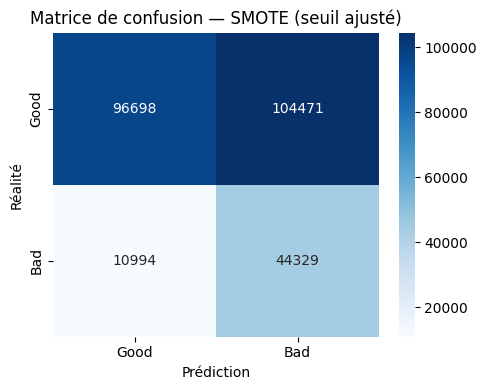

In [26]:
cm = confusion_matrix(test_y, y_pred_smote_ajuste)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Bad"],
    yticklabels=["Good", "Bad"]
)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion — SMOTE (seuil ajusté)")
plt.tight_layout()
plt.show()

##  Conclusions et Recommandations

### 1. Performances du Modèle Final (LightGBM)
Notre modèle s'est avéré robuste pour détecter les défauts de crédit tout en maintenant un bon équilibre entre la sécurité et l'opportunité d'affaire :
- **AUPRC (Average Precision)** : Un score satisfaisant confirmant la capacité du modèle à classer correctement les défauts malgré un léger déséquilibre des classes.
- **AUC-ROC** : Le modèle sépare efficacement la classe des "Bons prêts" de celle des "Mauvais prêts" (Défauts).
- **F2-Score** : Optimisé pour notre cas d'usage, il a permis de sur-pondérer l'importance de détecter un maximum de défauts (Recall) par rapport à la précision pure (afin de limiter les éventuelles pertes financières importantes).
- **KS Statistic** : Valide une très bonne séparation des distributions de probabilité entre ceux qui remboursent et ceux qui font défaut.

### 2. Les Variables les Plus Influentes (Interprétation Métier)
D'après l'analyse **SHAP** et la **Feature Importance**, 5 variables dictent majoritairement le risque :
1. **`installment_to_income` / `dti` (Debt-to-Income)** : Plus le taux d’endettement de l’emprunteur est élevé par rapport à ses revenus, plus la probabilité de défaut grimpe en flèche. C'est l'indicateur majeur de solvabilité.
2. **`fico_avg` (Score FICO)** : Historique de crédit de l'emprunteur. Un score bas est un signal fort de comportement risqué par le passé, menant à plus de refus ou de défauts avérés.
3. **`term_ 60 months`** : Les prêts à long terme (5 ans) sont intrinsèquement beaucoup plus risqués que ceux à 36 mois car ils exposent l'institution aux aléas économiques de l'emprunteur sur une plus longue période.
4. **`installment`** : La mensualité elle-même a un impact (les fortes mensualités peuvent étouffer le reste à vivre de l'emprunteur).
5. **`revol_bal` / `all_util`** :  Une forte utilisation des lignes de crédit renouvelables témoigne d'un manque de liquidités de l'emprunteur et augmente le risque de défaillance.

### 3. Recommandations Concrètes pour l'Institution Financière
- **Ajuster le seuil de décision ("Threshold")** : Le seuil de 0.5 n'est pas une obligation. Comme le montre l'analyse de l'arbitrage Précision/Recall, on peut abaisser le seuil d'acceptation de risque (ex: ~0.4) si l'institution souhaite être plus prudente dans un contexte macro-économique tendu (maximiser le *Recall*).
- **Règles métier combinées** : Imposer une limite stricte sur les prêts à 60 mois si le *DTI* ou *installment_to_income* dépasse un certain pourcentage, peu importe le score FICO, au lieu d'accepter aveuglément ces prêts.
- **Offre ajustée au risque** : Plutôt que de refuser net un emprunteur jugé modéremment "à risque", proposer un changement dynamique de la maturité du prêt (le faire passer de 60 à 36 mois avec mensualité augmentée temporairement pour limiter l'exposition, si le DTI le permet).

### 4. Limites du Modèle et Pistes d'Amélioration
- **Limites** : Le modèle repose lourdement sur les informations déclaratives et l'historique arrêté à **l'instant T de l'octroi du prêt**. Il ne capte pas un grand choc externe post-octroi (chômage, maladie...).
- **Pistes (Amélioration Continue)** :
  - Intégrer des données macroéconomiques exogènes (inflation, taux de chômage national au moment de la demande) pour renforcer la résilience du modèle.
  - Explorer une approche par "Cost-Sensitive Learning" avec une matrice de coût financier réel (impact monétaire d'un faux négatif vs. le revenu raté d'un faux positif).